In [1]:
import sys
!{sys.executable} -m pip install numpy pandas scipy matplotlib scikit-learn


In [4]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [5]:
# Simulate market data
np.random.seed(42)
n_samples = 200

S = np.random.uniform(80, 120, n_samples)
K = np.random.uniform(80, 120, n_samples)
T = np.random.uniform(0.1, 2, n_samples)
r = 0.05
sigma = np.random.uniform(0.1, 0.4, n_samples)

# Black-Scholes call prices
def bs_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

bs_prices = bs_call(S, K, T, r, sigma)

# Simulate market prices with some noise
market_prices = bs_prices + np.random.normal(0, 2, n_samples)

# Residuals
residuals = market_prices - bs_prices

# Create DataFrame
df = pd.DataFrame({'S': S, 'K': K, 'T': T, 'sigma': sigma, 'BS_price': bs_prices,
                   'market_price': market_prices, 'residual': residuals})
df.head()


,S,K,T,sigma,BS_price,market_price,residual
0,94.981605,105.681266,0.295935,0.150681,0.535479,-1.045470,-1.580949
1,118.028572,83.365599,1.814851,0.183577,42.250886,43.193823,0.942937
2,109.279758,86.465149,1.059980,0.153103,27.478971,31.243020,3.764049
3,103.946339,115.942168,1.670269,0.126611,5.597340,8.288180,2.690840
4,86.240746,104.257162,0.708094,0.136191,0.439431,3.625805,3.186373


In [6]:
# Features for ML: S, K, T, sigma
X = df[['S', 'K', 'T', 'sigma']]
y = df['residual']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict residuals
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error on residuals: {mse:.4f}")


Mean Squared Error on residuals: 3.5183


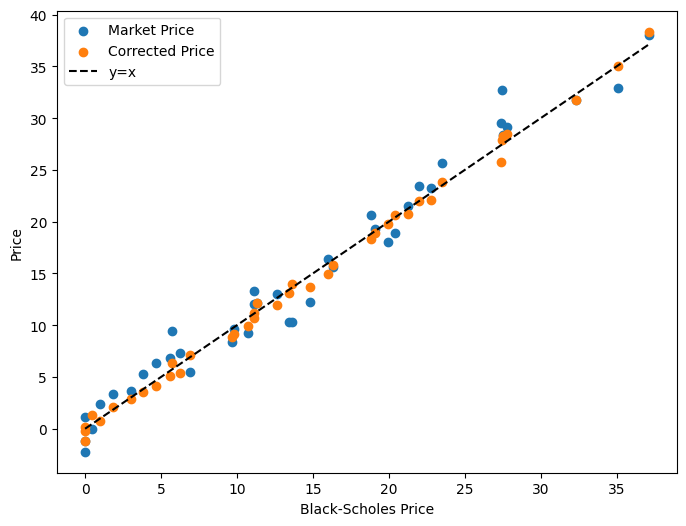

In [7]:
# Corrected prices
bs_test = df.loc[X_test.index, 'BS_price']
corrected_prices = bs_test + y_pred

# Compare
plt.figure(figsize=(8,6))
plt.scatter(bs_test, df.loc[X_test.index, 'market_price'], label='Market Price')
plt.scatter(bs_test, corrected_prices, label='Corrected Price')
plt.plot([bs_test.min(), bs_test.max()], [bs_test.min(), bs_test.max()], 'k--', label='y=x')
plt.xlabel("Black-Scholes Price")
plt.ylabel("Price")
plt.legend()
plt.show()
